# Simulation_CLP_delai

In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, FO_RT, Delay_RT
from package_LAB import PID_RT, LL_RT, IMC_Tuning


# Load data

In [130]:
nameFile1 = 'RT_PID_FF_2026-03-28-03h55.txt' #50s
nameFile2 = 'RT_PID_delai_2026-03-28-04h53.txt' #100s
nameFile3 = 'RT_PID_delai_2026-03-28-06h16.txt' #170s
nameFile4 = 'RT_PID_delai_2026-03-28-07h07.txt' #250s
nameFile = 'RT_PID_delai_2026-03-28-16h24.txt' #0s


titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)
titleName1 = nameFile1.split('.')[0]    
data1 = pd.read_csv('Data/' + nameFile1)
titleName2 = nameFile2.split('.')[0]    
data2 = pd.read_csv('Data/' + nameFile2)
titleName3 = nameFile3.split('.')[0]    
data3 = pd.read_csv('Data/' + nameFile3)
titleName4 = nameFile4.split('.')[0]    
data4 = pd.read_csv('Data/' + nameFile4)

tm = data['t'].values
MVm = data['MV'].values
PVm = data['PV'].values
tm1 = data1['t'].values
MVm1 = data1['MV'].values
PVm1 = data1['PV'].values
tm2 = data2['t'].values
MVm2 = data2['MV'].values
PVm2 = data2['PV'].values
tm3 = data3['t'].values
MVm3 = data3['MV'].values
PVm3 = data3['PV'].values
tm4 = data4['t'].values
MVm4 = data4['MV'].values
PVm4 = data4['PV'].values

MVPm = data['MVP'].values
MVIm = data['MVI'].values
MVDm = data['MVD'].values
MVPm2 = data2['MVP'].values
MVIm2 = data2['MVI'].values
MVDm2 = data2['MVD'].values
MVPm4 = data4['MVP'].values
MVIm4 = data4['MVI'].values
MVDm4 = data4['MVD'].values


In [131]:
Kp = 0.36
Tp1 = 170.82
Tp2 = 26.55
thetap = 13.31

Kd = 0.31
Td1 = 161.20
Td2 = 32.3
thetad = 15.75

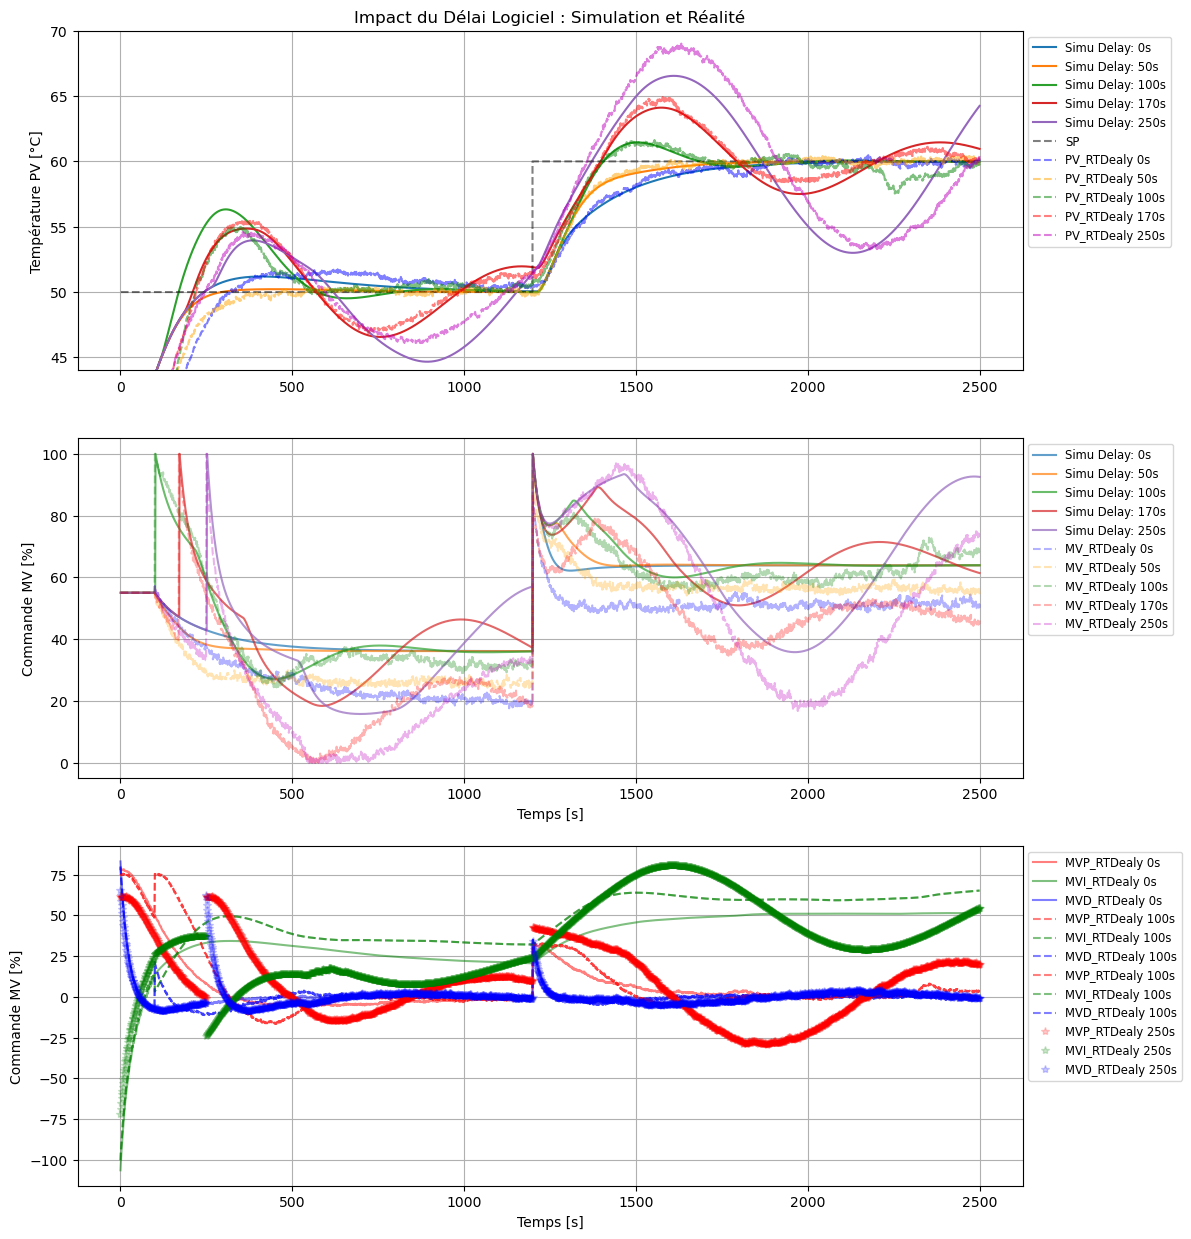

In [132]:

TSim = 2500
Ts = 1 
N = int(TSim/Ts) + 1

PV0 = 55
MV0= 50
DV0 = 50

K_FF = -Kd / Kp
theta_FF = max(0, thetad - thetap)


delais_test = [0, 50, 100, 170, 250]
alpha = 0.9
gamma = 0.9
MVMin = 0
MVMax = 100
booléan = False
Kc, Ti, Td = IMC_Tuning(Kp, Tp1, thetap, T2=Tp2, tauc=gamma*Tp1, model='SOPDT')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15))

for L_add in delais_test:
   
    t, DV, SP, Man, MVMan = [], [], [], [], []
    DV_delta, DV_delay, MVFF_step1, MVFF = [], [], [], []
    E, MV, MVP, MVI, MVD = [], [], [], [], []
    MVDelayp, PV1p, PV2p, PV = [], [], [], []
    MVDelayd, PV1d, PV2d = [], [], []

    DVPath = {0: 50, 2500: 50, TSim: 50}
    SPPath = {0: 50, 1200: 60, TSim: 60}
    ManPath = {0: True, 100: False, TSim: False}
    MVManPath = {0: 55, TSim: 55}

    for i in range(1, N):
        t.append(i * Ts)
        SelectPath_RT(DVPath, t, DV)
        SelectPath_RT(SPPath, t, SP)
        SelectPath_RT(ManPath, t, Man)
        SelectPath_RT(MVManPath, t, MVMan) 
        
        DV_delta.append(DV[-1] - DV0)
        Delay_RT(DV_delta, theta_FF, Ts, DV_delay)
        LL_RT(DV_delay, K_FF, Tp1, Td1, Ts, MVFF_step1, method='EBD')
        LL_RT(MVFF_step1, 1.0 if booléan else 0.0, Tp2, Td2, Ts, MVFF, method='EBD')
        
        if len(PV) > L_add:
            PV_delayed = [PV[-L_add-1]]
        else:
            PV_delayed = [PV[-1]] if len(PV) > 0 else [PV0]
            
        PID_RT(SP, PV_delayed, Man, MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF = booléan)

        Delay_RT(MV, thetap, Ts, MVDelayp, MV0)
        FO_RT(MVDelayp, Kp, Tp1, Ts, PV1p)
        FO_RT(PV1p, 1, Tp2, Ts, PV2p)
       
        Delay_RT(DV_delta, thetad, Ts, MVDelayd)
        FO_RT(MVDelayd, Kd, Td1, Ts, PV1d)
        FO_RT(PV1d, 1, Td2, Ts, PV2d)

        PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)

    ax1.plot(t, PV, label=f'Simu Delay: {L_add}s')
    ax2.plot(t, MV, label=f'Simu Delay: {L_add}s', alpha=0.7)

# --- Courbes Réelles (PV) ---
ax1.step(t, SP, 'k--', label='SP', alpha=0.5)
ax1.plot(tm, PVm, 'b--', label='PV_RTDealy 0s', alpha=0.5)
ax1.plot(tm1, PVm1, color='orange', linestyle='--', label='PV_RTDealy 50s', alpha=0.5)
ax1.plot(tm2, PVm2, 'g--', label='PV_RTDealy 100s', alpha=0.5)
ax1.plot(tm3, PVm3, 'r--', label='PV_RTDealy 170s', alpha=0.5)
ax1.plot(tm4, PVm4, 'm--', label='PV_RTDealy 250s', alpha=0.5)

ax1.set_ylabel('Température PV [°C]')
ax1.set_title('Impact du Délai Logiciel : Simulation et Réalité')
ax1.set_ylim(44, 70)
ax1.grid(True)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

ax2.plot(tm, MVm, 'b--', label='MV_RTDealy 0s', alpha=0.3)
ax2.plot(tm1, MVm1, color='orange', linestyle='--', label='MV_RTDealy 50s', alpha=0.3)
ax2.plot(tm2, MVm2, 'g--', label='MV_RTDealy 100s', alpha=0.3)
ax2.plot(tm3, MVm3, 'r--', label='MV_RTDealy 170s', alpha=0.3)
ax2.plot(tm4, MVm4, 'm--', label='MV_RTDealy 250s', alpha=0.3)

ax2.set_ylabel('Commande MV [%]')
ax2.set_xlabel('Temps [s]')
ax2.grid(True)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

ax3.plot(tm, MVPm, 'r-', label='MVP_RTDealy 0s', alpha=0.5)
ax3.plot(tm, MVIm, 'g-', label='MVI_RTDealy 0s', alpha=0.5)
ax3.plot(tm, MVDm, 'b-', label='MVD_RTDealy 0s', alpha=0.5)
ax3.plot(tm2, MVPm2, 'r--', label='MVP_RTDealy 100s', alpha=0.5)
ax3.plot(tm2, MVIm2, 'g--', label='MVI_RTDealy 100s', alpha=0.5)
ax3.plot(tm2, MVDm2, 'b--', label='MVD_RTDealy 100s', alpha=0.5)
ax3.plot(tm2, MVPm2, 'r--', label='MVP_RTDealy 100s', alpha=0.5)
ax3.plot(tm2, MVIm2, 'g--', label='MVI_RTDealy 100s', alpha=0.5)
ax3.plot(tm2, MVDm2, 'b--', label='MVD_RTDealy 100s', alpha=0.5)
ax3.plot(tm4, MVPm4, 'r*', label='MVP_RTDealy 250s', alpha=0.2)
ax3.plot(tm4, MVIm4, 'g*', label='MVI_RTDealy 250s', alpha=0.2)
ax3.plot(tm4, MVDm4, 'b*', label='MVD_RTDealy 250s', alpha=0.2)

ax3.set_ylabel('Commande MV [%]')
ax3.set_xlabel('Temps [s]')
ax3.grid(True)
ax3.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')

plt.subplots_adjust(right=0.8) 
plt.show()